# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products = pd.read_csv('/datasets/products.csv', sep=';')
aisles = pd.read_csv('/datasets/aisles.csv', sep=';')
departments = pd.read_csv('/datasets/departments.csv', sep=';')
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

In [3]:
display(orders.head())
orders.info(show_counts=True)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [4]:
display(products.head())
products.info(show_counts=True)

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [5]:
display(aisles.head())
aisles.info(show_counts=True)

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [6]:
display(departments.head())
departments.info(show_counts=True)

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


In [7]:
display(order_products.head())
order_products.info(show_counts=True)

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Conclusiones

En este paso revisamos la estructura general de los datos. Observamos 5 tablas relacionadas por identificadores (order_id, product_id, aisle_id, department_id). También identificamos desde el inicio posibles problemas esperables del enunciado: valores ausentes en columnas específicas y duplicados en algunas tablas. En el siguiente paso corregiremos tipos de datos, trataremos ausentes y eliminaremos duplicados para dejar los datos listos para análisis.

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [8]:

orders.duplicated().sum()


15

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

In [9]:
dup_orders = orders[orders.duplicated(keep=False)].sort_values(by=['order_id','user_id'])
dup_orders.head(20)


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
354993,391768,57671,19,3,2,10.0
371905,391768,57671,19,3,2,10.0
119251,408114,68324,4,3,2,18.0
321100,408114,68324,4,3,2,18.0
250626,467134,63189,21,3,2,2.0
394347,467134,63189,21,3,2,2.0
99462,794638,50898,24,3,2,2.0
145574,794638,50898,24,3,2,2.0
242618,1021560,53767,3,3,2,9.0
311713,1021560,53767,3,3,2,9.0


Si aparecen muchos duplicados concentrados en esa combinación (miércoles 2am), sugiere un problema sistemático de captura/carga (ETL) para ese segmento de datos, más que un comportamiento real de usuarios.

In [10]:
orders = orders.drop_duplicates(subset=['order_id'], keep='first')
print(f"Filas después de eliminar duplicados: {orders.shape[0]}")

Filas después de eliminar duplicados: 478952


In [11]:
print(f"Duplicados por order_id: {orders.duplicated(subset=['order_id']).sum()}")
print(f"Duplicados completos: {orders.duplicated().sum()}")


Duplicados por order_id: 0
Duplicados completos: 0


In [12]:
orders.duplicated(subset=['order_id']).sum()


0

Se identificaron duplicados en orders (filas completas repetidas). Al parecer están asociados a un patrón específico de día/hora, lo cual sugiere un error de procesamiento. Se eliminaron duplicados completos para evitar doble conteo en análisis posteriores y se verificó que order_id no quede duplicado.

### `products` data frame

In [13]:
products.duplicated().sum()

0

In [14]:

products.duplicated(subset=['product_id']).sum()

0

In [15]:
# nombres duplicados no faltantes (si hay NaN, se excluyen del análisis)
non_missing_names = products[products['product_name'].notna()].copy()
non_missing_names['product_name_upper'] = non_missing_names['product_name'].str.upper()
non_missing_names.duplicated(subset=['product_name_upper']).sum()


104

Se revisaron duplicados completos, por product_id y por nombre (normalizado a mayúsculas). Los duplicados por nombre pueden ser válidos si productos distintos comparten nombre o si existen variaciones, pero duplicados completos no aportan información y se eliminaron.

### `departments` data frame

In [16]:
departments.duplicated().sum()

0

In [17]:
departments.duplicated(subset=['department_id']).sum()

0

Se revisaron duplicados completos y por department_id. Se eliminaron duplicados completos para asegurar que cada departamento sea único y no genere duplicidad en merges.

### `aisles` data frame

In [18]:
aisles.duplicated().sum()

0

In [19]:
aisles.duplicated(subset=['aisle_id']).sum()

0

Se revisaron duplicados completos y por aisle_id. Se eliminaron duplicados completos para asegurar correspondencia 1 a 1 entre aisle_id y el nombre del pasillo.

### `order_products` data frame

In [20]:
order_products.duplicated().sum()


0

In [21]:
# "duplicados engañosos": mismas claves order_id + product_id (y quizá mismo add_to_cart_order)
order_products.duplicated(subset=['order_id','product_id','add_to_cart_order']).sum()

0

Se revisaron duplicados completos y duplicados por combinación de columnas clave. No , se encontraron filas duplicadas para evitar inflar conteos de productos por orden.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [22]:
products['product_name'].isna().sum()


1258

Al parecer hay 1258 valores ausentes

In [23]:
missing_products = products[products['product_name'].isna()]

In [24]:
missing_products['aisle_id'].value_counts().head(10)



100    1258
Name: aisle_id, dtype: int64

Se identificaron 1258 valores ausentes en la columna product_name.
Al analizar su distribución por aisle_id, se observó que todos los productos con nombre ausente pertenecen al pasillo con aisle_id = 100.

Esto indica que los valores faltantes no están distribuidos aleatoriamente, sino que están concentrados en un único pasillo específico.

In [25]:
(missing_products['department_id'] == 21).all()

True

Se confirmó que todos los productos con nombre ausente también pertenecen al department_id = 21.

Esto refuerza la conclusión de que los valores faltantes están concentrados en una categoría específica (pasillo 100, departamento 21) y no distribuidos de manera aleatoria en el dataset.

In [26]:
(missing_products['department_id'] == 21).all()

departments[departments['department_id'] == 21]

,department_id,department
20,21,missing


Se verificó que el department_id = 21 corresponde al departamento llamado "missing". Esto confirma que los productos con nombre ausente están asociados a una categoría creada específicamente para datos faltantes.

Por lo tanto, la ausencia en product_name parece estar intencionalmente agrupada bajo un departamento y pasillo identificados como "missing", lo que refuerza que no se trata de un error aleatorio sino de registros incompletos dentro de una categoría específica.

In [27]:
products['product_name'] = products['product_name'].fillna('Unknown')
products['product_name'].isna().sum()


0

Los valores ausentes en la columna product_name fueron reemplazados exitosamente por "Unknown". Tras la imputación, la verificación confirma que ya no existen valores nulos en esta columna (0 valores ausentes).

Esto asegura que la variable está completa y lista para análisis posteriores sin riesgo de errores por datos faltantes.

### `orders` data frame

In [28]:
orders['days_since_prior_order'].isna().sum()

28817

In [29]:
missing_days = orders[orders['days_since_prior_order'].isna()]
missing_days['order_number'].value_counts().head()



1    28817
Name: order_number, dtype: int64

In [30]:
(missing_days['order_number'] == 1).all()

True

In [31]:
orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(0)
orders['days_since_prior_order'].isna().sum()

0

Los ausentes en days_since_prior_order corresponden al primer pedido (order_number == 1), por lo que es razonable imputarlos con 0 (no hay un pedido anterior del cual calcular días). Esto permite graficar y analizar sin perder esas órdenes.

### `order_products` data frame

In [32]:
order_products['add_to_cart_order'].isna().sum()

836

In [33]:
order_products['add_to_cart_order'].min(), order_products['add_to_cart_order'].max()

(1.0, 64.0)

In [34]:
missing_cart_orders = order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()
len(missing_cart_orders)

70

Aunque hay 836 registros faltantes, estos pertenecen solo a 70 pedidos, lo que indica que el problema de datos faltantes está localizado en ciertos pedidos específicos y no distribuido de forma uniforme en todo el dataset.

In [35]:
missing_cart_orders = order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()
len(missing_cart_orders)

70

In [36]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.

counts_missing = (
    order_products[order_products['order_id'].isin(missing_cart_orders)]
    .groupby('order_id')['product_id']
    .count()
)

counts_missing.min(), counts_missing.max()


(65, 127)

Al analizar los pedidos que tienen valores ausentes en add_to_cart_order, se encontró que el número de productos por pedido varía entre 65 y 127 productos. Esto indica que todos los pedidos con valores faltantes tienen más de 64 productos.

Este resultado sugiere que los valores ausentes probablemente aparecen porque la columna add_to_cart_order solo registra posiciones hasta 64, y cuando un pedido supera ese número de productos, el orden de los productos adicionales no se guarda y aparece como valor faltante.

In [37]:
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999).astype('int')
order_products['add_to_cart_order'].isna().sum()


0

Los ausentes en add_to_cart_order aparecen en pedidos con una cantidad muy alta de productos (a menudo >64), lo cual sugiere un límite o error técnico al registrar el orden de añadido al carrito. Para conservar los productos del pedido sin inventar un orden real, se imputó un valor marcador (999) y se convirtió a entero..

## Conclusiones

En el preprocesamiento se identificaron duplicados en varias tablas y se eliminaron para evitar sesgos en los conteos. Los valores ausentes se analizaron antes de imputarlos: days_since_prior_order faltaba principalmente en el primer pedido del cliente y se imputó con 0; product_name se completó con "Unknown" para conservar productos; y add_to_cart_order se imputó con 999 como marcador debido a que los ausentes se concentran en pedidos grandes, sugiriendo un problema de registro. Tras estos cambios, los datos quedaron consistentes para el análisis exploratorio.


# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [38]:
orders['order_hour_of_day'].min(), orders['order_hour_of_day'].max()

(0, 23)

In [39]:
orders['order_dow'].min(), orders['order_dow'].max()

(0, 6)

Escribe aquí tus conclusiones

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

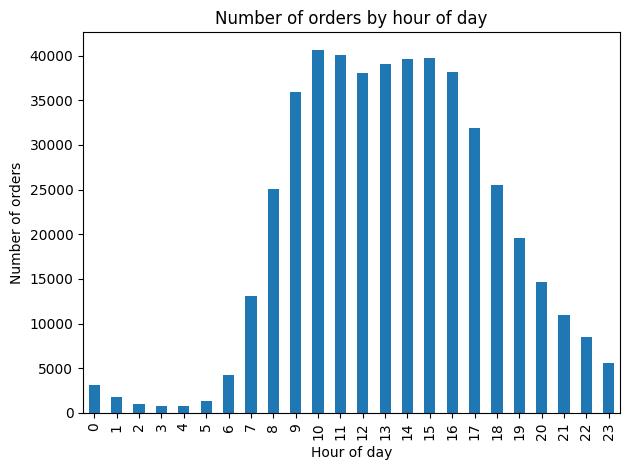

In [40]:
hour_counts = orders['order_hour_of_day'].value_counts().sort_index()

hour_counts.plot(kind='bar')
plt.title('Number of orders by hour of day')
plt.xlabel('Hour of day')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

### [A3] ¿Qué día de la semana compran víveres las personas?

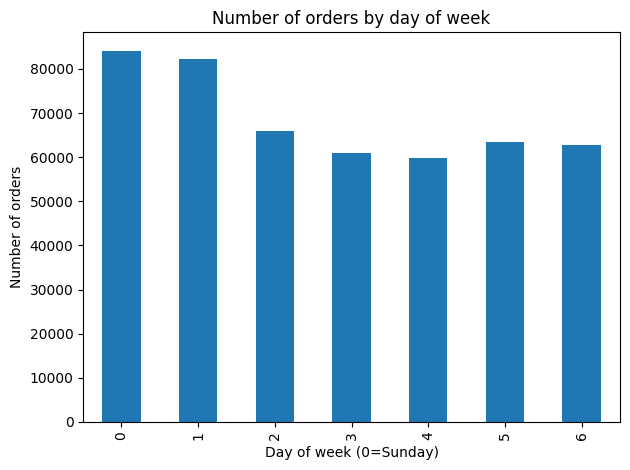

In [41]:
dow_counts = orders['order_dow'].value_counts().sort_index()

dow_counts.plot(kind='bar')
plt.title('Number of orders by day of week')
plt.xlabel('Day of week (0=Sunday)')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

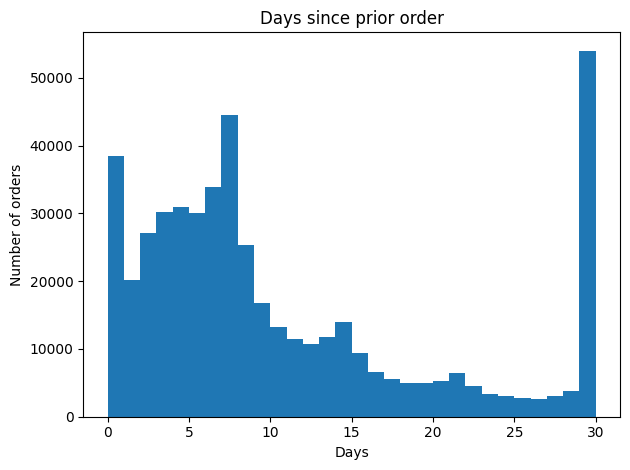

(0.0, 30.0)

In [42]:
orders['days_since_prior_order'].plot(kind='hist', bins=30)
plt.title('Days since prior order')
plt.xlabel('Days')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()

orders['days_since_prior_order'].min(), orders['days_since_prior_order'].max()

La distribución muestra que muchas personas vuelven a comprar después de pocos días. El valor mínimo es 0 (incluye primeros pedidos o casos de 0 días) y el máximo es 30 días. La cola hacia valores altos sugiere que algunos usuarios compran esporádicamente.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [43]:
wed_orders = orders[orders['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()

In [44]:
sat_orders = orders[orders['order_dow'] == 6]['order_hour_of_day'].value_counts().sort_index()
sat_orders

0      464
1      254
2      177
3      125
4      118
5      161
6      451
7     1619
8     3246
9     4311
10    4919
11    5116
12    5132
13    5323
14    5375
15    5188
16    5029
17    4295
18    3338
19    2610
20    1847
21    1473
22    1185
23     893
Name: order_hour_of_day, dtype: int64

In [45]:
compare_hours = pd.DataFrame({
    'Wednesday': wed_orders,
    'Saturday': sat_orders
}).fillna(0)

compare_hours

,Wednesday,Saturday
0,373,464
1,215,254
2,106,177
3,101,125
4,108,118
5,170,161
6,643,451
7,1732,1619
8,3125,3246
9,4490,4311


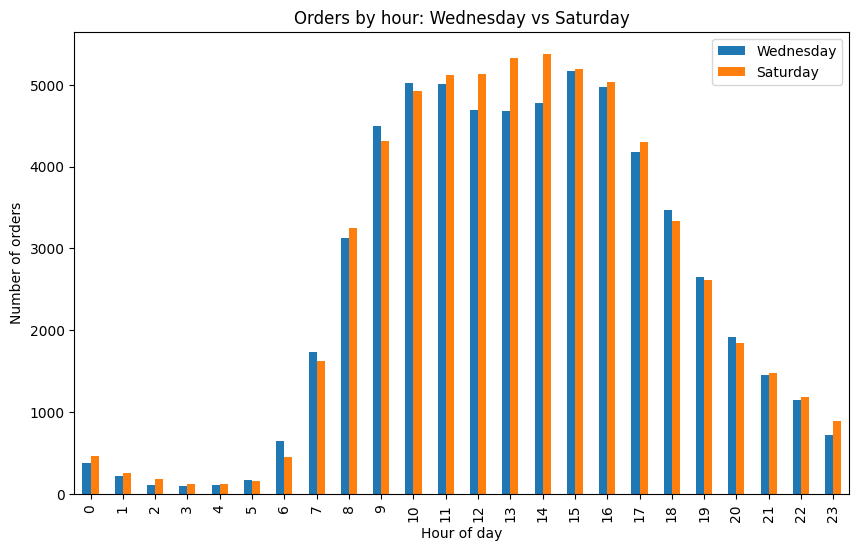

In [46]:
compare_hours.plot(kind='bar', figsize=(10,6))

plt.title('Orders by hour: Wednesday vs Saturday')
plt.xlabel('Hour of day')
plt.ylabel('Number of orders')
plt.legend()

plt.show()

Se observan patrones similares en ambos días, con poca actividad durante la madrugada y un aumento claro a partir de las 08:00. Los sábados muestran más pedidos que los miércoles entre 11:00 y 14:00, con un pico alrededor de 14:00. En cambio, los miércoles presentan valores ligeramente más altos en la tarde-noche, especialmente alrededor de 18:00–20:00. En general, ambos días alcanzan altos niveles de pedidos entre 10:00 y 16:00, pero el sábado concentra más actividad al mediodía, mientras que el miércoles mantiene una actividad relativamente mayor en horas posteriores de la tarde.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Identificaste correctamente una ligera disminución entre las 11h y las 13h los miércoles, que está ausente los sábados.

</div>

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [47]:
orders_per_user = orders.groupby('user_id')['order_id'].count()

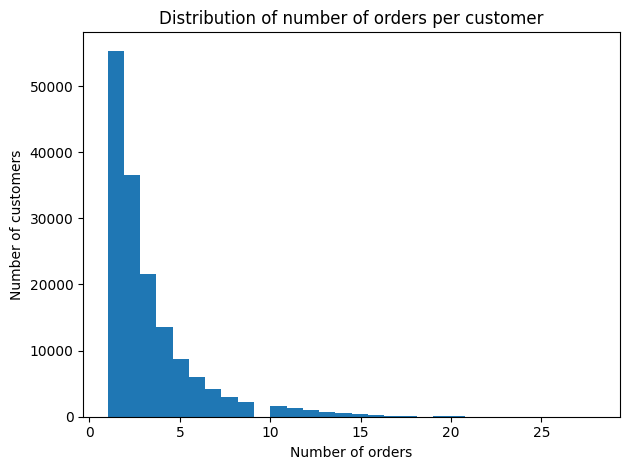

In [48]:
orders_per_user.plot(kind='hist', bins=30)
plt.title('Distribution of number of orders per customer')
plt.xlabel('Number of orders')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Excelente trabajo. Además el histograma es acertado. 

</div>

La distribución suele estar sesgada a la derecha: la mayoría de clientes realiza pocos pedidos y un grupo pequeño realiza muchos. Esto es típico en plataformas de compras recurrentes.

# B3 ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

In [51]:
top20 = order_products['product_id'].value_counts().head(20).reset_index()

top20.columns = ['product_id', 'order_count']

In [52]:
top20 = top20.merge(products[['product_id','product_name']], on='product_id', how='left')
top20

,product_id,order_count,product_name
0,24852,66050,Banana
1,13176,53297,Bag of Organic Bananas
2,21137,37039,Organic Strawberries
3,21903,33971,Organic Baby Spinach
4,47209,29773,Organic Hass Avocado
5,47766,24689,Organic Avocado
6,47626,21495,Large Lemon
7,16797,20018,Strawberries
8,26209,19690,Limes
9,27845,19600,Organic Whole Milk


Los 20 productos más pedidos reflejan artículos de consumo frecuente. Esta lista ayuda a identificar “productos estrella” y puede ser útil para inventario, promociones y recomendaciones.

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [56]:
items_per_order = order_products.groupby('order_id')['product_id'].count()

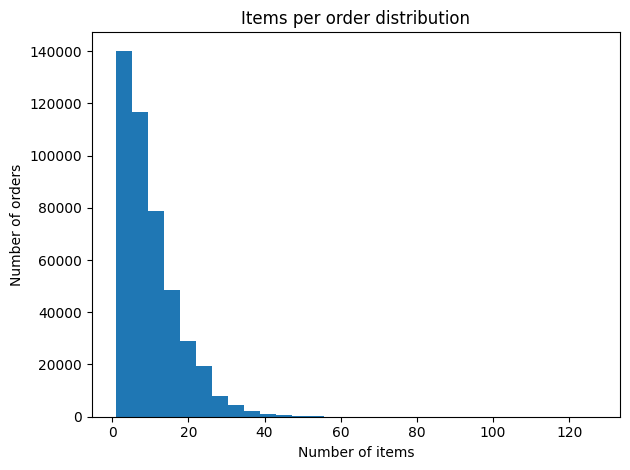

In [57]:
items_per_order.plot(kind='hist', bins=30)

plt.title('Items per order distribution')
plt.xlabel('Number of items')
plt.ylabel('Number of orders')

plt.tight_layout()
plt.show()

La distribución muestra que la mayoría de los pedidos contienen un número relativamente pequeño de artículos. Los pedidos más comunes se concentran en un rango bajo de productos por orden, mientras que los pedidos con muchos artículos son menos frecuentes. La distribución está sesgada hacia la derecha, lo que indica que aunque algunos pedidos contienen muchos productos, la mayoría de los clientes compran cantidades moderadas en cada pedido.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [59]:
top20_reordered = (
    order_products[order_products['reordered'] == 1]['product_id']
    .value_counts()
    .head(20)
    .reset_index()
)

In [60]:
top20_reordered.columns = ['product_id','reorder_count']

In [61]:
top20_reordered = top20_reordered.merge(products[['product_id','product_name']], on='product_id', how='left')
top20_reordered

,product_id,reorder_count,product_name
0,24852,55763,Banana
1,13176,44450,Bag of Organic Bananas
2,21137,28639,Organic Strawberries
3,21903,26233,Organic Baby Spinach
4,47209,23629,Organic Hass Avocado
5,47766,18743,Organic Avocado
6,27845,16251,Organic Whole Milk
7,47626,15044,Large Lemon
8,27966,14748,Organic Raspberries
9,16797,13945,Strawberries


Los resultados muestran que los productos más reordenados son principalmente frutas y alimentos frescos, como bananas, fresas orgánicas, espinaca orgánica y aguacates. Esto sugiere que los clientes tienden a volver a comprar productos básicos y perecederos con mayor frecuencia. Además, la presencia de varios productos orgánicos entre los más reordenados indica una preferencia significativa por este tipo de alimentos dentro de la plataforma.

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [62]:
reorder_ratio = (
    order_products.groupby('product_id')['reordered']
    .mean()
    .reset_index()
    .rename(columns={'reordered':'reorder_ratio'})
)


In [63]:
reorder_ratio = reorder_ratio.merge(products[['product_id','product_name']], on='product_id', how='left')
reorder_ratio.head()

,product_id,reorder_ratio,product_name
0,1,0.564286,Chocolate Sandwich Cookies
1,2,0.000000,All-Seasons Salt
2,3,0.738095,Robust Golden Unsweetened Oolong Tea
3,4,0.510204,Smart Ones Classic Favorites Mini Rigatoni Wit...
4,7,0.500000,Pure Coconut Water With Orange


La columna reorder_ratio representa la proporción de veces que un producto fue reordenado respecto a todas sus apariciones. Productos con ratio alto tienden a ser compras recurrentes (básicos), mientras que ratios bajos pueden representar compras ocasionales o de prueba.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [64]:
op_users = order_products.merge(orders[['order_id','user_id']], on='order_id', how='left')

user_reorder_ratio = (
    op_users.groupby('user_id')['reordered']
    .mean()
    .reset_index()
    .rename(columns={'reordered':'user_reorder_ratio'})
)


In [65]:
user_reorder_ratio.head()

,user_id,user_reorder_ratio
0,2,0.038462
1,4,0.000000
2,5,0.666667
3,6,0.000000
4,7,0.928571


Esta métrica muestra qué tan “recurrente” es cada cliente: valores altos indican que suele repetir productos; valores bajos sugieren exploración o compras no repetidas. Es útil para segmentación (clientes fieles vs exploradores).

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [66]:
top20_first = (
    order_products[order_products['add_to_cart_order'] == 1]['product_id']
    .value_counts()
    .head(20)
    .reset_index()
)

In [67]:
top20_first.columns = ['product_id','first_in_cart_count']

In [68]:
top20_first = top20_first.merge(products[['product_id','product_name']], on='product_id', how='left')
top20_first

,product_id,first_in_cart_count,product_name
0,24852,15562,Banana
1,13176,11026,Bag of Organic Bananas
2,27845,4363,Organic Whole Milk
3,21137,3946,Organic Strawberries
4,47209,3390,Organic Hass Avocado
5,21903,3336,Organic Baby Spinach
6,47766,3044,Organic Avocado
7,19660,2336,Spring Water
8,16797,2308,Strawberries
9,27966,2024,Organic Raspberries


Los productos que aparecen con mayor frecuencia como “primero en el carrito” pueden representar artículos prioritarios o “ancla” del pedido. Esto puede ser útil para entender qué motiva el inicio de compra.

### Conclusion general del proyecto:

En este proyecto se realizó la limpieza, preprocesamiento y análisis exploratorio del conjunto de datos de Instacart para comprender mejor los hábitos de compra de los clientes. 
Durante el proceso de limpieza se identificaron valores duplicados y valores ausentes en diferentes tablas. Los duplicados fueron eliminados para evitar distorsiones en el análisis, mientras que los valores ausentes fueron tratados de forma adecuada:
por ejemplo, los nombres de productos faltantes se reemplazaron por "Unknown" y los valores faltantes en days_since_prior_order se interpretaron como el primer pedido de un cliente.

El análisis exploratorio reveló patrones claros en el comportamiento de compra. La mayor parte de los pedidos se realizan durante el día, especialmente entre las 10:00 y 16:00 horas, mientras que la actividad disminuye considerablemente durante la madrugada.
Además, se observó que los sábados presentan un mayor número de pedidos alrededor del mediodía, mientras que los miércoles mantienen una actividad relativamente mayor durante la tarde.

También se encontró que la mayoría de los clientes realiza pedidos con un número moderado de artículos, aunque existe una distribución sesgada donde algunos pedidos contienen muchos productos.
En cuanto a los productos más populares y más reordenados, predominan frutas, verduras y productos frescos, especialmente bananas, fresas y aguacates, lo que indica que los clientes tienden a repetir la compra de alimentos básicos y perecederos. 
Asimismo, varios de los productos más solicitados pertenecen a la categoría de productos orgánicos, lo que sugiere una preferencia relevante por este tipo de alimentos.

En conjunto, estos resultados muestran patrones consistentes de compra en la plataforma, donde los usuarios realizan pedidos principalmente durante el día y tienden a repetir productos básicos de consumo frecuente.
Estos hallazgos pueden ser útiles para comprender el comportamiento de los clientes y para optimizar recomendaciones de productos, gestión de inventario y estrategias comerciales dentro de la plataforma.